# Importing necessary libraries

In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
# import numpy as np
plt.rcParams['figure.dpi']=100
from scipy import stats
from sklearn.decomposition import PCA

# Load Dataset

In [ ]:
!gdown --id 1kFR51NiTY4mhb2j_7OqoDdj8cCiEcPHq
ds=pd.read_csv(r'ecg.csv',header=None)
data=ds.iloc[:,:-1].values
target=ds.iloc[:,-1].to_numpy()

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:138: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1kFR51NiTY4mhb2j_7OqoDdj8cCiEcPHq
To: /content/ecg.csv
100% 7.88M/7.88M [00:00<00:00, 30.9MB/s]


# Plot ECG

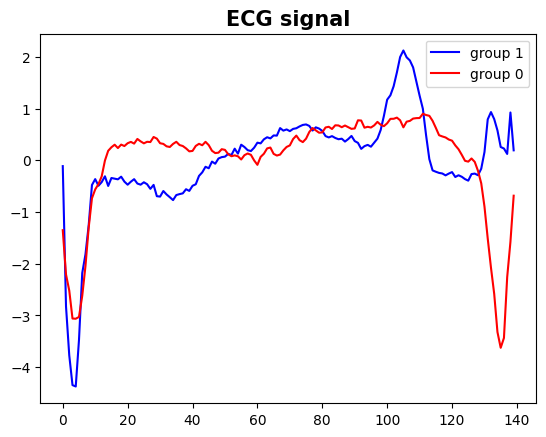

In [ ]:
plt.plot(data[0,:],'b')
plt.plot(data[-1,:],'r')
plt.legend({'group 0','group 1'})
plt.title('ECG signal',fontsize=15,fontweight='bold')
plt.show()

# Statistical Features

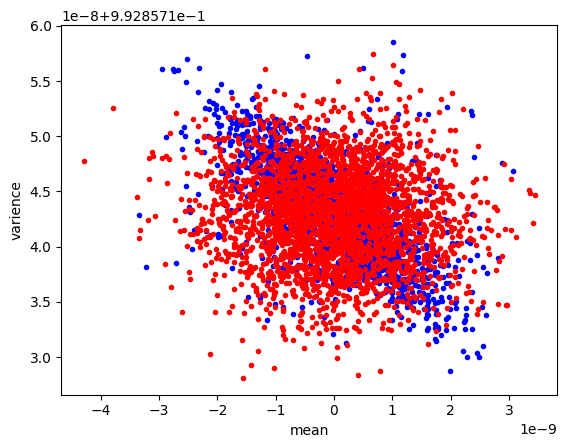

In [ ]:
mu= data.mean(axis=1)
sd= data.var(axis=1)
sk= stats.skew(data,axis=1)
plt.plot(mu[target==0],sd[target==0],'.b')
plt.plot(mu[target==1],sd[target==1],'.r')
# fig = plt.figure(figsize=plt.figaspect(0.5))
# ax = fig.add_subplot(1,1,1,projection='3d')
# ax.scatter3D(mu[target==0],sd[target==0],sk[target==0],'red')
# ax.scatter3D(mu[target==1],sd[target==1],sk[target==1],'blue')
plt.xlabel('mean')
plt.ylabel('varience')
plt.show()

# Feature extraction using principal component analysis(PCA)

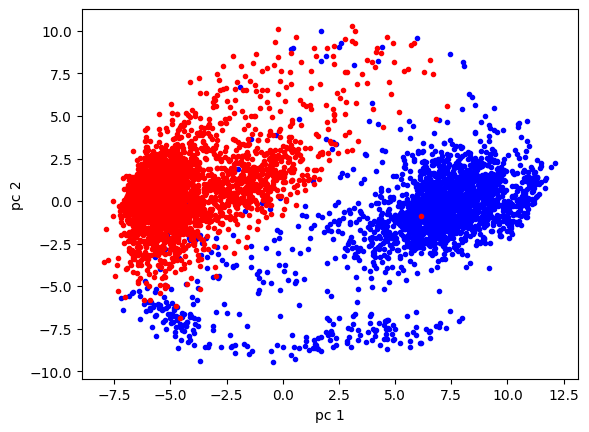

In [ ]:
pca= PCA(n_components=3)
pca.fit(data)
features= pca.transform(data)
plt.plot(features[target==0,0],features[target==0,1],'.b')
plt.plot(features[target==1,0],features[target==1,1],'.r')
# fig = plt.figure(figsize=plt.figaspect(0.5))
# ax = fig.add_subplot(1,1,1,projection='3d')
# ax.scatter3D(features[target==0,0],features[target==0,1],features[target==0,2],'red')
# ax.scatter3D(features[target==1,0],features[target==1,1],features[target==1,2],'blue')
plt.xlabel('pc 1')
plt.ylabel('pc 2')
plt.show()